In [1]:
!pip install numpy opencv-python-headless openvino matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


################|| Downloading person-vehicle-bike-detection-2000 ||################

========== Downloading /workspaces/codespaces-jupyter/notebooks/intel/person-vehicle-bike-detection-2000/FP16/person-vehicle-bike-detection-2000.xml
... 100%, 248 KB, 1218 KB/s, 0 seconds passed

========== Downloading /workspaces/codespaces-jupyter/notebooks/intel/person-vehicle-bike-detection-2000/FP16/person-vehicle-bike-detection-2000.bin
... 28%, 1024 KB, 3016 KB/s, 0 seconds passed
... 57%, 2048 KB, 5010 KB/s, 0 seconds passed
... 86%, 3072 KB, 7349 KB/s, 0 seconds passed
... 100%, 3557 KB, 7481 KB/s, 0 seconds passed

Model loaded from: ./person-vehicle-bike-detection-2000.xml
Detected person with 97% confidence
Detected person with 55% confidence

Total objects detected: 2


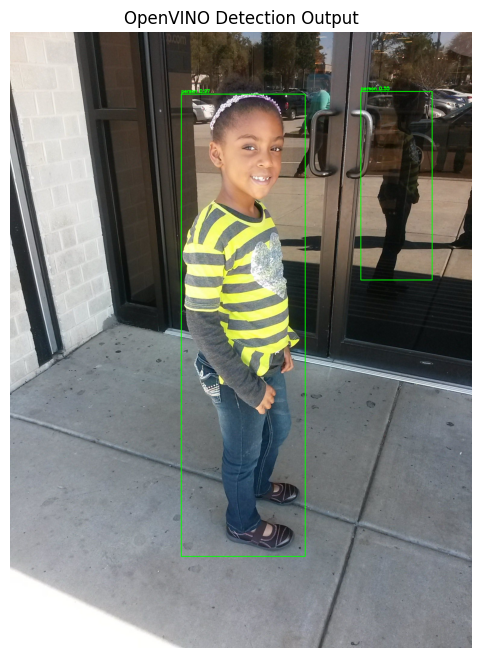

In [ ]:
# OpenVino for Computer Vision:An inference engine to generate predictions
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from openvino import Core

# STEP 1 Download Model (Run once if model is not present)
os.system("omz_downloader --name person-vehicle-bike-detection-2000 --precision FP16")

# STEP 2 Find Model File Automatically
model_xml = None

for root, dirs, files in os.walk("."):
    if "person-vehicle-bike-detection-2000.xml" in files:
        model_xml = os.path.join(root, "person-vehicle-bike-detection-2000.xml")
        break

if model_xml is None:
    raise FileNotFoundError("Model file not found. Run downloader first.")

print("Model loaded from:", model_xml)

# STEP 3 Load OpenVINO Model
ie = Core()

model = ie.read_model(model_xml)
compiled_model = ie.compile_model(model, "CPU")

input_layer = compiled_model.input(0)
output_layer = compiled_model.output(0)

_, _, H, W = input_layer.shape

# STEP 4Label Mapping (Model Specific)
labels = {
    1: "person",
    2: "vehicle",
    3: "bike"
}

# STEP 5 Load Image
image_path = "girleshae.jpg"

if not os.path.exists(image_path):
    raise FileNotFoundError("Please upload girleshae.jpg to project folder.")

image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

original = image_rgb.copy()

# STEP 6 Preprocess Input
resized = cv2.resize(image_rgb, (W, H))
input_tensor = np.expand_dims(resized.transpose(2, 0, 1), axis=0)

# STEP 7 Run Inference
results = compiled_model([input_tensor])[output_layer]

# STEP 8 Draw Detection Boxes
CONF_THRESHOLD = 0.3
detection_count = 0

for det in results[0][0]:

    confidence = float(det[2])
    class_id = int(det[1])

    if confidence > CONF_THRESHOLD and class_id in labels:

        detection_count += 1

        xmin = int(det[3] * original.shape[1])
        ymin = int(det[4] * original.shape[0])
        xmax = int(det[5] * original.shape[1])
        ymax = int(det[6] * original.shape[0])

        label = labels.get(class_id, "unknown")

        cv2.rectangle(original, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)

        cv2.putText(
            original,
            f"{label} {confidence:.2f}",
            (xmin, ymin - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            2
        )

        print(f"Detected {label} with {confidence:.0%} confidence")

# STEP 9 Summary Output
print(f"\nTotal objects detected: {detection_count}")

# STEP 10 Display Image Result
plt.figure(figsize=(8, 8))
plt.imshow(original)
plt.title("OpenVINO Detection Output")
plt.axis("off")
plt.show()
